In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = {
    'Student_ID' : [1,2,3,4,5,6,7,8,9,10],
    'Name' : ['Amit','Priya','Rohit','Sneha','Kiran','Neha','Raj','Pooja','Vikas','Anjali'],
    'Maths' : [85, 90, np.nan, 76, 95, 88, 45, 79, 300, 82],
    'Science' : [78, 85, 80, np.nan, 92, 87, 50, 76, 89, 84],
    'English' : [88, 92, 79, 75, 96, 85, 55, np.nan, 91, 80],
    'Attendance' : [92, 95, 88, 85, 98, np.nan, 65, 90, 94, 89]
}

In [3]:
df = pd.DataFrame(data)

In [4]:
print("Original Dataset:\n")
print(df)

Original Dataset:

   Student_ID    Name  Maths  Science  English  Attendance
0           1    Amit   85.0     78.0     88.0        92.0
1           2   Priya   90.0     85.0     92.0        95.0
2           3   Rohit    NaN     80.0     79.0        88.0
3           4   Sneha   76.0      NaN     75.0        85.0
4           5   Kiran   95.0     92.0     96.0        98.0
5           6    Neha   88.0     87.0     85.0         NaN
6           7     Raj   45.0     50.0     55.0        65.0
7           8   Pooja   79.0     76.0      NaN        90.0
8           9   Vikas  300.0     89.0     91.0        94.0
9          10  Anjali   82.0     84.0     80.0        89.0


In [5]:
# Check Missing Values
print("\nMissing Values:\n")
print(df.isnull().sum())


Missing Values:

Student_ID    0
Name          0
Maths         1
Science       1
English       1
Attendance    1
dtype: int64


In [9]:
# Handle Missing Values
# Replace missing numeric values with mean
df['Maths'] = df['Maths'].fillna(df['Maths'].mean())
df['Science'] = df['Science'].fillna(df['Science'].mean())
df['English'] = df['English'].fillna(df['English'].mean())
df['Attendance'] = df['Attendance'].fillna(df['Attendance'].mean())

In [10]:
print("\nDataset After Filling Missing Values:\n")
print(df)


Dataset After Filling Missing Values:

   Student_ID    Name       Maths    Science    English  Attendance
0           1    Amit   85.000000  78.000000  88.000000   92.000000
1           2   Priya   90.000000  85.000000  92.000000   95.000000
2           3   Rohit  104.444444  80.000000  79.000000   88.000000
3           4   Sneha   76.000000  80.111111  75.000000   85.000000
4           5   Kiran   95.000000  92.000000  96.000000   98.000000
5           6    Neha   88.000000  87.000000  85.000000   88.444444
6           7     Raj   45.000000  50.000000  55.000000   65.000000
7           8   Pooja   79.000000  76.000000  82.333333   90.000000
8           9   Vikas  300.000000  89.000000  91.000000   94.000000
9          10  Anjali   82.000000  84.000000  80.000000   89.000000


In [11]:
# Check Inconsistencies
# Example: Marks should be between 0 and 100
# Here Maths = 300 is inconsistent
df.loc[df['Maths'] > 100, 'Maths'] = df['Maths'].median()

In [12]:
print("\nDataset After Removing Inconsistencies:\n")
print(df)


Dataset After Removing Inconsistencies:

   Student_ID    Name  Maths    Science    English  Attendance
0           1    Amit   85.0  78.000000  88.000000   92.000000
1           2   Priya   90.0  85.000000  92.000000   95.000000
2           3   Rohit   86.5  80.000000  79.000000   88.000000
3           4   Sneha   76.0  80.111111  75.000000   85.000000
4           5   Kiran   95.0  92.000000  96.000000   98.000000
5           6    Neha   88.0  87.000000  85.000000   88.444444
6           7     Raj   45.0  50.000000  55.000000   65.000000
7           8   Pooja   79.0  76.000000  82.333333   90.000000
8           9   Vikas   86.5  89.000000  91.000000   94.000000
9          10  Anjali   82.0  84.000000  80.000000   89.000000


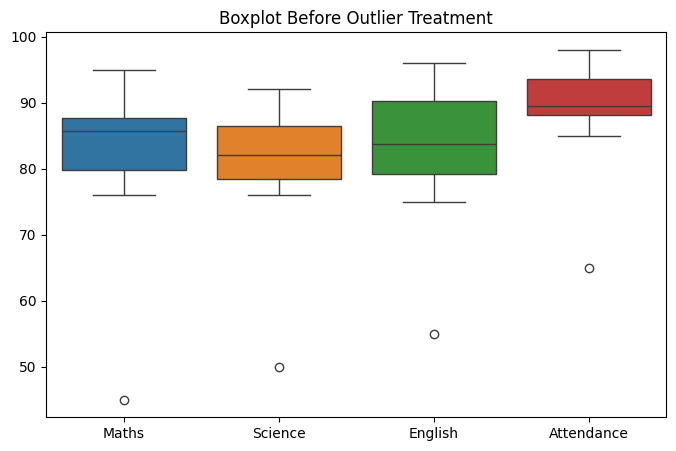

In [13]:
# STEP 6: Detect Outliers using Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['Maths','Science','English','Attendance']])
plt.title("Boxplot Before Outlier Treatment")
plt.show()

In [14]:
# --------------------------------------------------
# Remove Outliers using IQR Method
# --------------------------------------------------


In [15]:
numeric_cols = ['Maths','Science','English','Attendance']

for col in numeric_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

print("\nDataset After Outlier Treatment:\n")
print(df)


Dataset After Outlier Treatment:

   Student_ID    Name    Maths    Science    English  Attendance
0           1    Amit  85.0000  78.000000  88.000000   92.000000
1           2   Priya  90.0000  85.000000  92.000000   95.000000
2           3   Rohit  86.5000  80.000000  79.000000   88.000000
3           4   Sneha  76.0000  80.111111  75.000000   85.000000
4           5   Kiran  95.0000  92.000000  96.000000   98.000000
5           6    Neha  88.0000  87.000000  85.000000   88.444444
6           7     Raj  67.9375  66.500000  62.750000   80.027778
7           8   Pooja  79.0000  76.000000  82.333333   90.000000
8           9   Vikas  86.5000  89.000000  91.000000   94.000000
9          10  Anjali  82.0000  84.000000  80.000000   89.000000


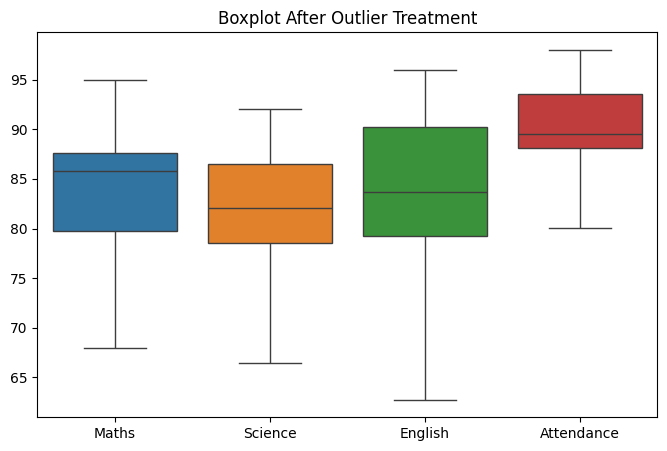

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['Maths','Science','English','Attendance']])
plt.title("Boxplot After Outlier Treatment")
plt.show()

In [17]:
# Apply Log Transformation on Attendance
# Purpose: Reduce Skewness
# --------------------------------------------------
df['Attendance_Log'] = np.log(df['Attendance'])

print("\nDataset After Log Transformation:\n")
print(df[['Attendance','Attendance_Log']])


Dataset After Log Transformation:

   Attendance  Attendance_Log
0   92.000000        4.521789
1   95.000000        4.553877
2   88.000000        4.477337
3   85.000000        4.442651
4   98.000000        4.584967
5   88.444444        4.482375
6   80.027778        4.382374
7   90.000000        4.499810
8   94.000000        4.543295
9   89.000000        4.488636


In [18]:
# --------------------------------------------------
# Histogram Before and After Transformation
# --------------------------------------------------

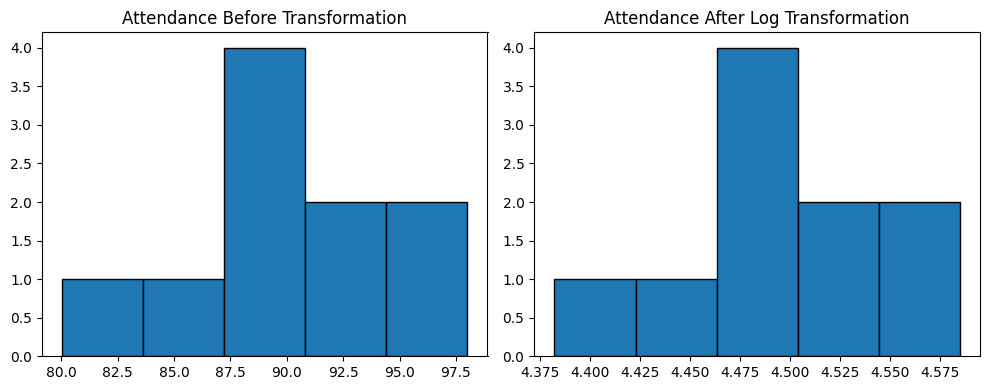

In [19]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(df['Attendance'], bins=5, edgecolor='black')
plt.title("Attendance Before Transformation")

plt.subplot(1,2,2)
plt.hist(df['Attendance_Log'], bins=5, edgecolor='black')
plt.title("Attendance After Log Transformation")

plt.tight_layout()
plt.show()

In [20]:
print("\nFinal Cleaned Dataset:\n")
print(df)


Final Cleaned Dataset:

   Student_ID    Name    Maths    Science    English  Attendance  \
0           1    Amit  85.0000  78.000000  88.000000   92.000000   
1           2   Priya  90.0000  85.000000  92.000000   95.000000   
2           3   Rohit  86.5000  80.000000  79.000000   88.000000   
3           4   Sneha  76.0000  80.111111  75.000000   85.000000   
4           5   Kiran  95.0000  92.000000  96.000000   98.000000   
5           6    Neha  88.0000  87.000000  85.000000   88.444444   
6           7     Raj  67.9375  66.500000  62.750000   80.027778   
7           8   Pooja  79.0000  76.000000  82.333333   90.000000   
8           9   Vikas  86.5000  89.000000  91.000000   94.000000   
9          10  Anjali  82.0000  84.000000  80.000000   89.000000   

   Attendance_Log  
0        4.521789  
1        4.553877  
2        4.477337  
3        4.442651  
4        4.584967  
5        4.482375  
6        4.382374  
7        4.499810  
8        4.543295  
9        4.488636  
